In [1]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/lncAPNet/Pilot_2_Prostate/notebooks/Post-hoc_Analysis


In [2]:
import os
import pandas as pd
import numpy as np

In [3]:
# Load TSV file
rumma_disease = pd.read_csv("../../results/Rumma/Rumma_geo_disease.tsv", sep="\t")
rumma_andro = pd.read_csv("../../results/Rumma/Rumma_geo_prostate_andro.tsv", sep="\t")
rumma_gene = pd.read_csv("../../results/Rumma/Rumma_Gene.tsv", sep="\t")

rumma_gene = pd.read_csv("../../results/Rumma/Rumma_Gene.tsv", sep="\t")
rumma_geo = pd.read_csv("../../results/Rumma/Rumma_geo_prostate_andro.tsv", sep="\t")

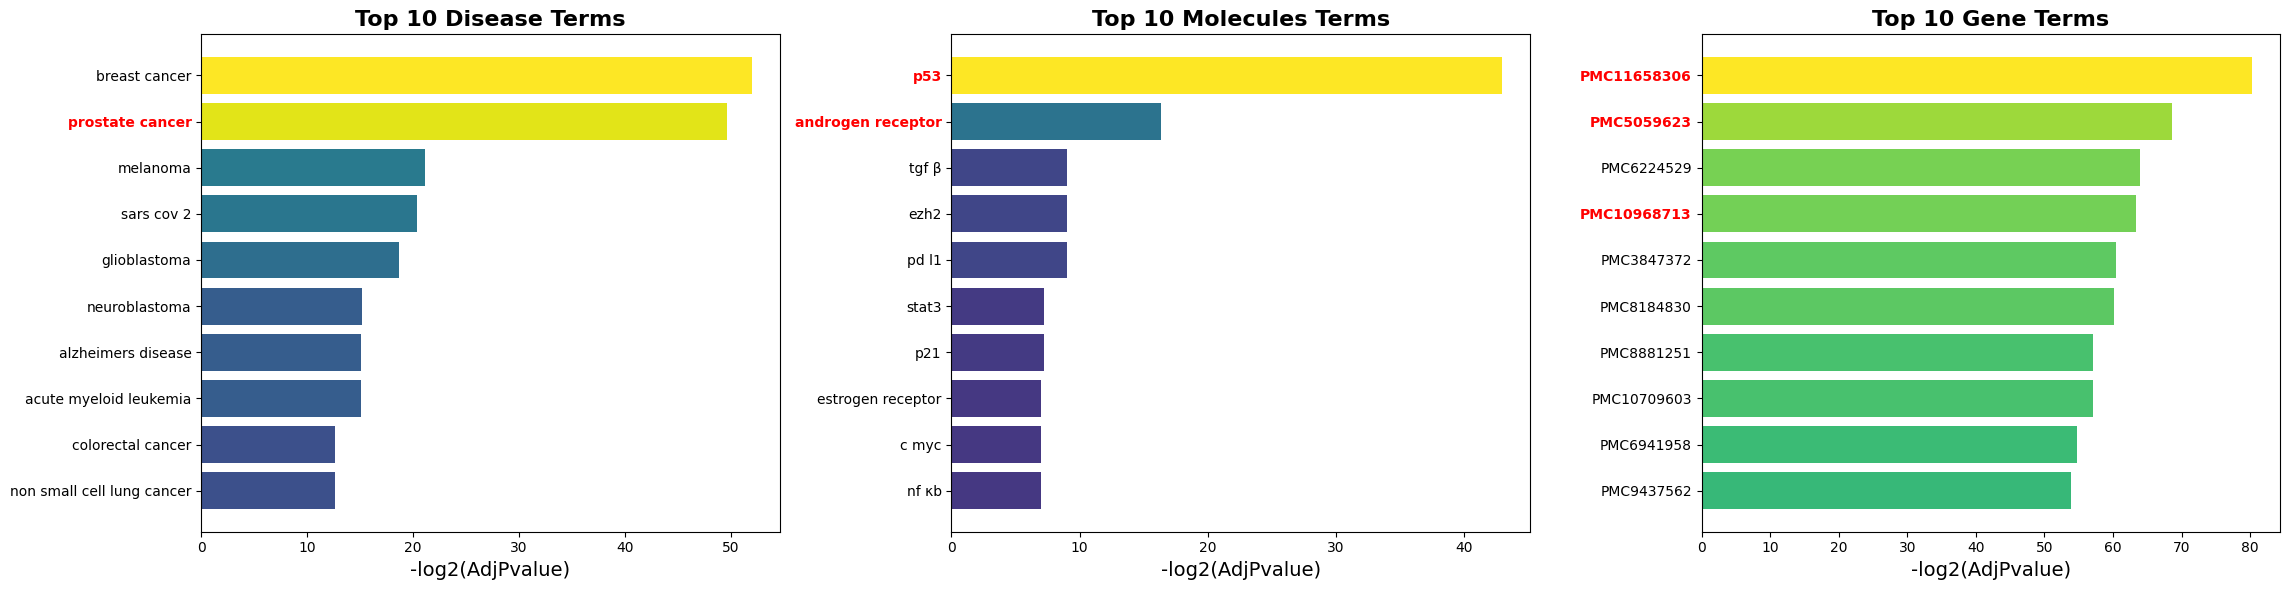

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -------------------------
# Load datasets
# -------------------------
rumma_disease = pd.read_csv("../../results/Rumma/Rumma_geo_disease.tsv", sep="\t")
rumma_andro = pd.read_csv("../../results/Rumma/Rumma_geo_prostate_andro.tsv", sep="\t")
rumma_gene = pd.read_csv("../../results/Rumma/Rumma_Gene.tsv", sep="\t")

# Remove duplicates in gene dataset
rumma_gene = rumma_gene.drop_duplicates(subset='pmcid')

# PMCIDs related to prostate adenocarcinoma
prostate_pmcs = ['PMC11658306', 'PMC5059623', 'PMC10968713']

# -------------------------
# Prepare top 10 for each dataset
# -------------------------
def prepare_top10(df, pval_col):
    df[pval_col] = pd.to_numeric(df[pval_col], errors='coerce')
    df = df[df[pval_col] > 0]
    df['neg_log2_AdjP'] = -np.log2(df[pval_col])
    top10 = df.nlargest(10, 'neg_log2_AdjP')
    return top10.sort_values('neg_log2_AdjP', ascending=True)

df_disease = prepare_top10(rumma_disease, 'AdjPvalue')
df_andro = prepare_top10(rumma_andro, 'AdjPvalue')
df_gene = prepare_top10(rumma_gene, 'adjPvalue')

# -------------------------
# Plot
# -------------------------
fig, axes = plt.subplots(1, 3, figsize=(23, 6), sharey=False)

datasets = [(df_disease, 'term', 'Top 10 Disease Terms'),
            (df_andro, 'term', 'Top 10 Molecules Terms'),
            (df_gene, 'pmcid', 'Top 10 Gene Terms')]

# Terms to highlight
disease_highlight = ['prostate cancer']
andro_highlight = ['p53', 'androgen receptor']

for idx, (df, ycol, title) in enumerate(datasets):
    df_sorted = df.sort_values('neg_log2_AdjP', ascending=True)
    colors = plt.cm.viridis(df_sorted['neg_log2_AdjP'] / df_sorted['neg_log2_AdjP'].max())
    bars = axes[idx].barh(df_sorted[ycol], df_sorted['neg_log2_AdjP'], color=colors)
    
    axes[idx].set_title(title, fontsize=16, fontweight='bold')
    axes[idx].set_xlabel("-log2(AdjPvalue)", fontsize=14)
    
    # Customize y-axis labels
    axes[idx].set_yticks(range(len(df_sorted)))
    axes[idx].set_yticklabels(df_sorted[ycol])
    
    for i, label in enumerate(axes[idx].get_yticklabels()):
        if ycol == 'pmcid' and df_sorted[ycol].iloc[i] in prostate_pmcs:
            label.set_color('red')
            label.set_fontweight('bold')
        elif ycol == 'term':
            if title == 'Top 10 Disease Terms' and df_sorted[ycol].iloc[i] in disease_highlight:
                label.set_color('red')
                label.set_fontweight('bold')
            elif title == 'Top 10 Molecules Terms' and df_sorted[ycol].iloc[i] in andro_highlight:
                label.set_color('red')
                label.set_fontweight('bold')

plt.tight_layout()
plt.savefig('../../figures/rumma_gene_geo.png', dpi=300)  # Save as high-res PNG
plt.show()


In [4]:
# Load TSV file

rumma_gene = pd.read_csv("../../results/Rumma/Rumma_Gene.tsv", sep="\t")
rumma_geo = pd.read_csv("../../results/Rumma/Rumma_geo_prostate_andro.tsv", sep="\t")

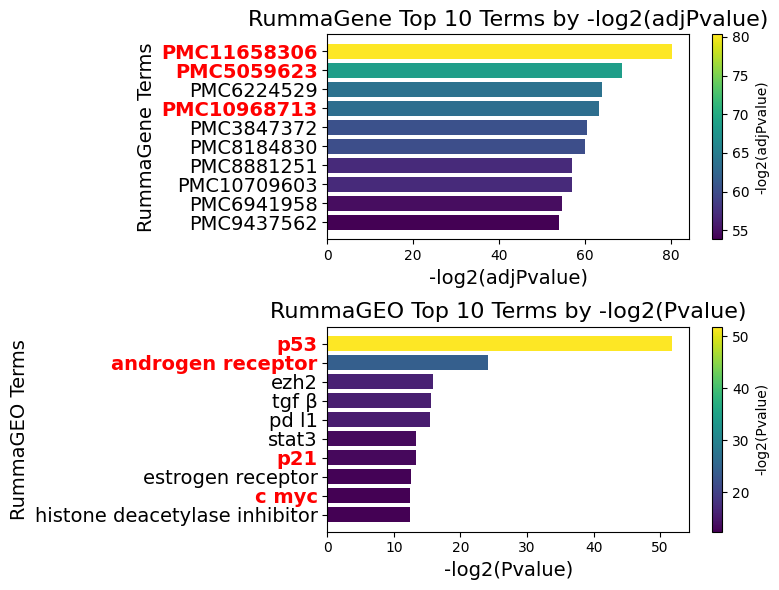

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import re

# --- Prepare the first dataset: rumma_gene ---
rumma_gene["-log2(adjPvalue)"] = -np.log2(rumma_gene["adjPvalue"])

# Replace long column names with shorter versions
long_name = "Top500_increased_var_genes-Column_ICGC_Top_500_genes_with_increased_variability_in_U-CLL_in_the_ICGC_dataset_total_number_of_genes_analyzed_20_474"
short_name = "Increased_variability_in_U-CLL_in_the_ICGC_dataset"
rumma_gene["column"] = rumma_gene["column"].replace(long_name, short_name)

# Remove duplicates by pmcid (keep the lowest adjPvalue per pmcid)
rumma_gene = rumma_gene.sort_values("adjPvalue", ascending=True).drop_duplicates("pmcid")

# Take top 10 by significance
df_top5 = rumma_gene.sort_values("-log2(adjPvalue)", ascending=False).head(10)
df_top5 = df_top5.sort_values("-log2(adjPvalue)", ascending=True)

# Color mapping
norm1 = mcolors.Normalize(vmin=df_top5["-log2(adjPvalue)"].min(),
                          vmax=df_top5["-log2(adjPvalue)"].max())
cmap1 = cm.viridis

# Highlight specific pmcids
highlight_pmcs = ['PMC11658306', 'PMC5059623', 'PMC10968713']

# --- Prepare the second dataset: rumma_geo ---
rumma_geo["-log2(Pvalue)"] = -np.log2(rumma_geo["Pvalue"])

df_top10 = rumma_geo.sort_values("-log2(Pvalue)", ascending=False).head(10)
df_top10 = df_top10.sort_values("-log2(Pvalue)", ascending=True)

# Clean up term names
def clean_term(term):
    term = re.sub(r"\s+WP\d+$", "", term)
    term = re.sub(r"\s+MP:?\d+$", "", term)
    term = re.sub(r"\s+\(GO:[^)]+\)$", "", term)
    term = re.sub(r"\s+MEGAKARYOCYTES.*$", "", term, flags=re.IGNORECASE)
    term = re.sub(r"\s+MEGAKA\w*$", "", term, flags=re.IGNORECASE)
    return term.strip()

df_top10["term_clean"] = df_top10["term"].apply(clean_term)

# Color mapping
norm2 = mcolors.Normalize(vmin=df_top10["-log2(Pvalue)"].min(),
                          vmax=df_top10["-log2(Pvalue)"].max())
cmap2 = cm.viridis

# Terms of interest to highlight
highlight_term = ["p53", "androgen receptor", "c myc", "p21"]  # must match cleaned terms

# --- Create 2x1 figure ---
fig, axes = plt.subplots(2, 1, figsize=(8, 6))  # 2 rows, 1 column

# Font sizes
y_label_fontsize = 14
x_label_fontsize = 14
title_fontsize = 16

# --- Top panel: rumma_gene ---
ax = axes[0]
bars1 = ax.barh(
    df_top5["pmcid"],
    df_top5["-log2(adjPvalue)"],
    color=cmap1(norm1(df_top5["-log2(adjPvalue)"]))
)

for label in ax.get_yticklabels():
    label.set_fontsize(y_label_fontsize)
    if label.get_text() in highlight_pmcs:
        label.set_color("red")
        label.set_fontweight("bold")

ax.set_xlabel("-log2(adjPvalue)", fontsize=x_label_fontsize)
ax.set_ylabel("RummaGene Terms", fontsize=x_label_fontsize)
ax.set_title("RummaGene Top 10 Terms by -log2(adjPvalue)", fontsize=title_fontsize)

sm1 = cm.ScalarMappable(cmap=cmap1, norm=norm1)
sm1.set_array([])
fig.colorbar(sm1, ax=ax, label="-log2(adjPvalue)")

# --- Bottom panel: rumma_geo ---
ax = axes[1]
bars2 = ax.barh(
    df_top10["term_clean"],
    df_top10["-log2(Pvalue)"],
    color=cmap2(norm2(df_top10["-log2(Pvalue)"]))
)

for label in ax.get_yticklabels():
    label.set_fontsize(y_label_fontsize)
    if label.get_text() in highlight_term:  # corrected
        label.set_color("red")
        label.set_fontweight("bold")

ax.set_xlabel("-log2(Pvalue)", fontsize=x_label_fontsize)
ax.set_ylabel("RummaGEO Terms", fontsize=x_label_fontsize)
ax.set_title("RummaGEO Top 10 Terms by -log2(Pvalue)", fontsize=title_fontsize)

sm2 = cm.ScalarMappable(cmap=cmap2, norm=norm2)
sm2.set_array([])
fig.colorbar(sm2, ax=ax, label="-log2(Pvalue)")

# --- Save and show ---
plt.tight_layout()
fig.savefig("../../figures/Rumma_top_panels_plot.png", dpi=300, bbox_inches="tight")
plt.show()


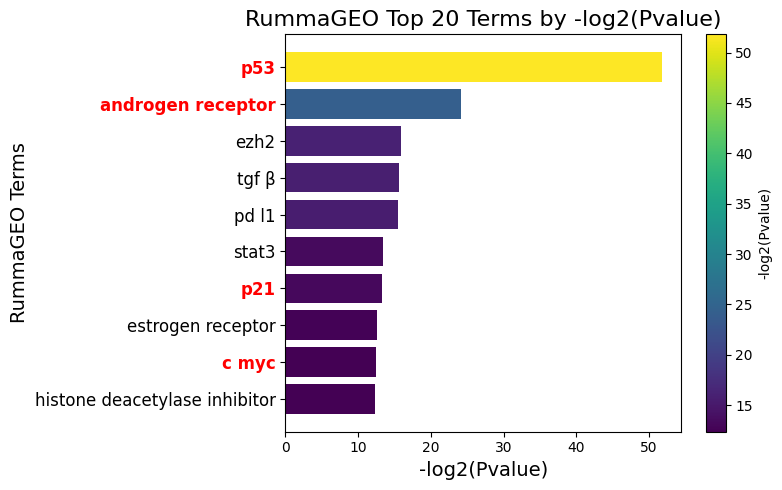

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import re

# --- Prepare the dataset: rumma_geo ---
rumma_geo["-log2(Pvalue)"] = -np.log2(rumma_geo["Pvalue"])

# Take top 20 instead of top 10
df_top20 = rumma_geo.sort_values("-log2(Pvalue)", ascending=False).head(10)
df_top20 = df_top20.sort_values("-log2(Pvalue)", ascending=True)

# Clean up term names
def clean_term(term):
    term = re.sub(r"\s+WP\d+$", "", term)
    term = re.sub(r"\s+MP:?\d+$", "", term)
    term = re.sub(r"\s+\(GO:[^)]+\)$", "", term)
    term = re.sub(r"\s+MEGAKARYOCYTES.*$", "", term, flags=re.IGNORECASE)
    term = re.sub(r"\s+MEGAKA\w*$", "", term, flags=re.IGNORECASE)
    return term.strip()

df_top20["term_clean"] = df_top20["term"].apply(clean_term)

# Color mapping
norm = mcolors.Normalize(vmin=df_top20["-log2(Pvalue)"].min(),
                         vmax=df_top20["-log2(Pvalue)"].max())
cmap = cm.viridis

# Terms to highlight
highlight_term = ["p53", "androgen receptor", "c myc", "p21"]

# Create figure (single panel)
fig, ax = plt.subplots(figsize=(8, 5))

# Plot
bars = ax.barh(
    df_top20["term_clean"],
    df_top20["-log2(Pvalue)"],
    color=cmap(norm(df_top20["-log2(Pvalue)"]))
)

# Highlight terms
for label in ax.get_yticklabels():
    label.set_fontsize(12)
    if label.get_text().lower() in highlight_term:
        label.set_color("red")
        label.set_fontweight("bold")

ax.set_xlabel("-log2(Pvalue)", fontsize=14)
ax.set_ylabel("RummaGEO Terms", fontsize=14)
ax.set_title("RummaGEO Top 20 Terms by -log2(Pvalue)", fontsize=16)

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="-log2(Pvalue)")

plt.tight_layout()
fig.savefig("../../figures/RummaGEO_finale.png", dpi=300, bbox_inches="tight")
plt.show()
